In [9]:
%%file numericsv2.py


import time

import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.constants as sc
from scipy.constants import convert_temperature
from scipy.optimize import fsolve
import h5py

import sympy as sym
import sys

    
font = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }
fontlabel = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }

from matplotlib.ticker import FormatStrFormatter
plt.rc('font', **font)


from scipy.optimize import fsolve
from scipy.sparse import csr_matrix
def nufd(x):
    n = len(x)
    h = x[1:]-x[:n-1]
    a0 = -(2*h[0]+h[1])/(h[0]*(h[0]+h[1]))
    ak = -h[1:]/(h[:n-2]*(h[:n-2]+h[1:]))
    an = h[-1]/(h[-2]*(h[-1]+h[-2]))
    b0 = (h[0]+h[1])/(h[0]*h[1]) 
    bk = (h[1:] - h[:n-2])/(h[:n-2]*h[1:])
    bn = -(h[-1]+h[-2])/(h[-1]*h[-2])
    c0 = -h[0]/(h[1]*(h[0]+h[1]))
    ck = h[:n-2]/(h[1:]*(h[:n-2]+h[1:]))
    cn = (2*h[-1]+h[-2])/(h[-1]*(h[-2]+h[-1]))
    val  = np.hstack((a0,ak,an,b0,bk,bn,c0,ck,cn))
    row = np.tile(np.arange(n),3)
    dex = np.hstack((0,np.arange(n-2),n-3))
    col = np.hstack((dex,dex+1,dex+2))
    D = csr_matrix((val,(row,col)),shape=(n,n))
    return D
def delta_tanh(gam,lx,xuni,dxwall):
        return lx/2.0*np.tanh(gam*(xuni[1]))/np.tanh(gam*lx/2.0)-(-lx/2 + dxwall)
class BoundaryConditions(object):
        """
        Set boundary conditions
        """
        def __init__(self,bc):
            self.names = bc
            self.value = np.empty(2)
        def set_value(self,whichend,val):
            if whichend == 'x0':
                self.value[0] = val
            elif whichend == 'x1':
                self.value[1] = val
            else:
                print("the 1st argument in set_value must be 'x0' or 'x1'")
                sys.exit(0)
class Grid(object):
    """ 
    How to:
    
    """
    def __init__(self,Nlayers,xlayers,NNodes_layer,delta_min):
        self.Nlayers = Nlayers
        self.xlayers = xlayers
        self.NNodes_per_layer = NNodes_layer
        self.delta_min = delta_min
        gam_guess = 6.0
        self.xs_layer = {}
        self.nodeends_layer = {}
        if (Nlayers == 1):
            Lx = self.xlayers[0,1] - self.xlayers[0,0]
            Nx = self.NNodes_per_layer[0]
            dx_wall = delta_min
            x_uni = np.linspace(-Lx/2, Lx/2, Nx)
            gamma_x = fsolve(delta_tanh, [gam_guess], args=(Lx,x_uni, dx_wall))
            x_s = Lx/2.0*np.tanh(gamma_x*(x_uni))/np.tanh(gamma_x*Lx/2.0)
            self.xs = x_s + self.xlayers[0,0] + Lx/2
            self.xs_layer[0] = self.xs 
            self.nodeends_layer[0] = np.array([0, x_s.shape[0]])
        else:
            for n in range(self.Nlayers):
                Lx = self.xlayers[n,1] - self.xlayers[n,0]
                Nx = self.NNodes_per_layer[n]
                dx_wall = delta_min
                x_uni = np.linspace(-Lx/2, Lx/2, Nx)
                gamma_x = fsolve(delta_tanh, [gam_guess], args=(Lx,x_uni, dx_wall))
                x_s = Lx/2.0*np.tanh(gamma_x*(x_uni))/np.tanh(gamma_x*Lx/2.0)
                if n == 0:
                    self.xs = x_s + self.xlayers[n,0] + Lx/2
                    self.nodeends_layer[0] = np.array([0, x_s.shape[0]-1])
                else:
                    self.xs = np.append(self.xs, x_s[1:] + self.xlayers[n,0] + Lx/2)
                    self.nodeends_layer[n] = [self.nodeends_layer[n-1][1],self.xs.shape[0]-1]
                self.xs_layer[n] = x_s + self.xlayers[n,0] + Lx/2
class Dump(object):
    def __init__(self,t,T,H_t,k,rhoCp,xs,Dx,initialize):
        N = T.shape[0]
        self.N = N
        self.k = k
        self.rhoCp = rhoCp
        self.xs = xs
        dataprofiles = np.zeros((1,N,2))
        dataprofiles[0,:,0] = xs.copy()
        dataprofiles[0,:,1] = T.copy()
        qppboth = np.zeros((1,2)) 
        dTdx = Dx*T
        qppboth[0][0] = -k[0]*dTdx[0]
        qppboth[0][1] = -k[-1]*dTdx[-1]
        if initialize:
            self.t = np.array([t])
            self.H_t = np.array([H_t])
            self.T = dataprofiles
            self.qppbnd = qppboth.copy()
            T_K = convert_temperature(T,"C","K")
            try:
                totalenthalpy = np.trapezoid(rhoCp*T_K,xs)
            except AttributeError:
                totalenthalpy = np.trapz(rhoCp*T_K,xs)
            self.enthalpy = np.array([totalenthalpy])
        else:
            self.t = np.concatenate((self.t,t))
            self.H_t = np.concatenate((self.H_t,H_t))
            self.T = np.concatenate((self.T, dataprofiles),axis=0)
            self.qppbnd = np.concatenate((self.qppbnd,qppboth),axis=0)
            T_K = convert_temperature(T,"C","K")
            try:
                totalenthalpy = np.trapezoid(rhoCp*T_K,xs)
            except AttributeError:
                totalenthalpy = np.trapz(rhoCp*T_K,xs)
            self.enthalpy = np.array([totalenthalpy])
    def update(self,t,T,H_t,k,rhoCp,xs,Dx):
        dataprofiles = np.zeros((1,self.N,2))
        dataprofiles[0,:,0] = xs.copy()
        dataprofiles[0,:,1] = T.copy()
        qppboth = np.zeros((1,2)) 
        dTdx = Dx*T
        qppboth[0][0] = -k[0]*dTdx[0]
        qppboth[0][1] = -k[-1]*dTdx[-1]
        
        self.t = np.concatenate((self.t,np.array([t])))
        self.H_t = np.concatenate((self.H_t,np.array([H_t])))
        self.T = np.concatenate((self.T, dataprofiles),axis=0)
        self.qppbnd = np.concatenate((self.qppbnd,qppboth),axis=0)
        T_K = convert_temperature(T,"C","K")
        try:
            totalenthalpy = np.trapezoid(rhoCp*T_K,xs)
        except AttributeError:
            totalenthalpy = np.trapz(rhoCp*T_K,xs)
        self.enthalpy = np.concatenate((self.enthalpy,[totalenthalpy]))
    def writefile(self,fname):
        f = h5py.File(fname,'w')
        print(self.t.shape)
        f.create_dataset('t',data = self.t[:])
        f.create_dataset('H_t',data = self.H_t[:])
        f.create_dataset('k',data = self.k)
        f.create_dataset('rhoCp',data = self.rhoCp)
        f.create_dataset('xs',data = self.xs)
        f.create_dataset('qppx0and1',data = self.qppbnd)
        f.create_dataset('Tprofiles',data = self.T[:,:,1])
        f.create_dataset('enthalpy',data = self.enthalpy)
        f.close()
        
        
            

class ConductionDomain(object):
    
    def __init__(self,Nlayers,xlayers,bcnames):
        """
        Create a domain to solve 1D conduction heat transfer. The domain is made of Nlayers,
        the coordinates of these layers is stored in the array xlayers, and boundary conditions are
        defined by the array bc 
        Input:
        - Nlayers (integer): number of layers
        - xlayers (array[Nlayers,2] of floats): xlayers[n,0] is the coordinate of the left boundary of layer n,
            xlayers[n,1], the coordinate of the righ boundary of layer n.
        - bcnames (array[2] of strings: bc[0] is the boundary condition at xlayers[0,0], 
            bc[1] at xlayers[-1,1]
        Output:
        - self.Nlayers
        - self.xlayers
        - self.bc (boundary condition object)
        example:
        Nlayer = 2
        xlayers = np.array([[0.0, 1.0], [1.0, 2.0]])
        wall = ConductionDomain(Nlayers,xlayers)
        """
        self.Nlayers = Nlayers
        self.xlayers = xlayers
        self.bc = BoundaryConditions(bcnames)

    def create_grid(self,NNodes_per_layers,delta_min):
        self.grid = Grid(self.Nlayers,self.xlayers,NNodes_per_layers,delta_min)
        
    def set_layers_thermodynamic_properties(self,k_per_layer,rho_per_layer,Cp_per_layer,
                                            qdot_per_layer=np.empty(0)):
        if (np.array(k_per_layer).shape[0] != self.Nlayers) :
            print(np.array(k_per_layer).shape)
            print("k_per_layer is an array of size %i. It must be of size (%i)" %(np.array(k_per_layer).shape[0],self.Nlayers))
            sys.exit(0)
        self.k_per_layer = np.array(k_per_layer)
        if (np.array(rho_per_layer).shape[0] != self.Nlayers) :
            print("rho_per_layer must be an array of size (%i)" %self.Nlayers)
            sys.exit(0)
        self.rho_per_layer = np.array(rho_per_layer)
        if (np.array(Cp_per_layer).shape[0] != self.Nlayers) :
            print("Cp_per_layer must be an array of size (%i)" %self.Nlayers)
            sys.exit(0)
        self.Cp_per_layer = np.array(Cp_per_layer)
        if (np.array(qdot_per_layer).shape[0] != self.Nlayers) :
            print("qdot_per_layer must be an array of size (%i)" %self.Nlayers)
            sys.exit(0)
        self.qdot_per_layer = np.array(qdot_per_layer)
        self.k = np.zeros_like(self.grid.xs)
        self.rhoCp = np.zeros_like(self.grid.xs)
        n = 0
        i = 0
        if self.Nlayers == 1:
            self.k[:] = self.k_per_layer[0]
            self.rhoCp[:] = self.rho_per_layer[0]*self.Cp_per_layer[0]
        else:
            for n in range(self.Nlayers):
                if n == 0:
                    istart = self.grid.nodeends_layer[n][0]
                else:
                    istart = self.grid.nodeends_layer[n][0] + 1
                if n == self.Nlayers -1:
                    iend = self.grid.nodeends_layer[n][1]
                    avg = False
                else:
                    iend = self.grid.nodeends_layer[n][1] - 1
                    avg = True
                self.k[istart:iend+1] = self.k_per_layer[n]
                self.rhoCp[istart:iend+1] = self.rho_per_layer[n]*self.Cp_per_layer[n]
                if avg:
                    self.k[iend+1] = 0.5*(self.k_per_layer[n+1] + self.k_per_layer[n])
                    self.rhoCp[iend+1] = 0.5*(self.rho_per_layer[n+1]*self.Cp_per_layer[n+1] + 
                                              self.rho_per_layer[n]*self.Cp_per_layer[n])
        # while i < self.grid.xs.shape[0]:
        #     if (self.grid.xs[i] > self.xlayers[n,1]):
        #         n += 1
        #     self.k[i] = self.k_per_layer[n]
        #     self.rhoCp[i] = self.rho_per_layer[n]*self.Cp_per_layer[n]
            # if (self.grid.xs[i] < self.xlayers[n,1]):
            #     self.k[i] = self.k_per_layer[n]
            #     self.rhoCp[i] = self.rho_per_layer[n]*self.Cp_per_layer[n]
            # else:
            #     n += 1
            #     if (self.Nlayers > 1) and (n < self.Nlayers -1):
            #         self.k[i] = 0.5*(self.k_per_layer[n] + self.k_per_layer[n-1])
            #         self.rhoCp[i] = 0.5*(self.rho_per_layer[n]*self.Cp_per_layer[n] +
            #                              self.rho_per_layer[n-1]*self.Cp_per_layer[n-1])
            #     else:
            #         self.k[i] = self.k_per_layer[n-1]
            #         self.rhoCp[i] = self.rho_per_layer[n-1]*self.Cp_per_layer[n-1]
            i += 1
    def create_metrics(self):
        self.metrics = Metrics(self.Nlayers,self.grid.xs,self.grid.xs_layer,self.k,self.bc)

    def solve_steady(self):
        d = np.zeros_like(self.metrics.a)
        d[0] = self.bc.value[0]
        d[-1] = self.bc.value[1]
        self.T = np.linalg.solve(self.metrics.DDx,d)
        self.qpp = -self.k[:]*self.metrics.Dx*self.T
        # return np.linalg.solve(self.metrics.DDx,d)
    def init_T(self,Tinit):
        assert Tinit.shape[0] == self.grid.xs.shape[0]
        self.T = Tinit.copy()
    def solve_unsteady(self,dt):
        a = self.metrics.a.copy()
        # b = mymetrics.b[1:-1].copy()
        c = self.metrics.c.copy()
        a *= dt/(2*self.rhoCp)
        c *= dt/(2*self.rhoCp)
        b = -(a + c)
        d = np.ones_like(self.T)
        x = self.grid.xs
        # print(d.shape,T.shape)
        d[1:-1] = a[1:-1]*self.T[:-2] + (b[1:-1] + 1)*self.T[1:-1] + c[1:-1]*self.T[2:]
        
        A = np.zeros((self.T.shape[0],self.T.shape[0]))
        if (self.bc.names[0] == 'Dirichlet'):
            b[0] = 1.
            A[0,0] = 1.
        elif (self.bc.names[0] == 'Neumann'):
            A[0,1] = -self.k[0]*(x[2] - x[0])/(x[1] - x[0])/(x[2] - x[1])
            A[0,2] = +self.k[0]*(x[1] - x[0])/(x[2] - x[0])/(x[2] - x[1])
            A[0,0] = -(A[0,1] + A[0,2])
            b[0] = A[0,0]
        else:
            print("typo in bc_x0")
        if (self.bc.names[1] == 'Dirichlet'):
            b[-1] = 1.
            A[-1,-1] = 1.
        elif (self.bc.names[1] == 'Neumann'):
            A[-1,-2] = -self.k[-1]*(x[-3] - x[-1])/(x[-2] - x[-1])/(x[-3] - x[-2])
            A[-1,-3] = +self.k[-1]*(x[-2] - x[-1])/(x[-3] - x[-1])/(x[-3] - x[-2])
            A[-1,-1] = -(A[-1,-2] + A[-1,-3])
            b[-1] = A[-1,-1]
        else:
            print("typo in bc_x1")
        d[0] = self.bc.value[0]
        d[-1] = self.bc.value[1]
        # print(d[0],d[-1])
        for i in range(1,self.T.shape[0]-1):
            A[i,i-1] = -a[i]
            A[i,i] = 1.0 - b[i]
            A[i,i+1] = -c[i]
        self.T = np.linalg.solve(A,d)

class Metrics(object):
    """
    Metrics for the computation of first and second spatial derivatives.
    """
    def __init__(self,nlayers,xs,xs_layer,conductivity,bc):
        self.Dx_layer = {}
        for n in range(nlayers):
            self.Dx_layer[n] = nufd(xs_layer[n])
        self.Dx = nufd(xs)
        a = np.zeros_like(xs)
        c = np.zeros_like(xs)
        k = conductivity.copy()
        x = xs.copy()
        A = np.zeros((x.shape[0],x.shape[0]))
        a[1:-1] = (k[1:-1] + k[:-2])/(x[2:] - x[:-2])/(x[1:-1] - x[:-2])
        c[1:-1] = (k[1:-1] + k[2:])/(x[2:] - x[:-2])/(x[2:] - x[1:-1])
        b = -(a+c)
        if (bc.names[0] == 'Dirichlet'):
            b[0] = 1.
        elif (bc.names[0] == 'Neumann'):
            A[0,1] = -k[0]*(x[2] - x[0])/(x[1] - x[0])/(x[2] - x[1])
            A[0,2] = +k[0]*(x[1] - x[0])/(x[2] - x[0])/(x[2] - x[1])
            A[0,0] = -(A[0,1] + A[0,2])
            b[0] = A[0,0]
        else:
            print("typo in bc_x0")
        if (bc.names[1] == 'Dirichlet'):
            b[-1] = 1.
        elif (bc.names[1] == 'Neumann'):
            A[-1,-2] = -k[-1]*(x[-3] - x[-1])/(x[-2] - x[-1])/(x[-3] - x[-2])
            A[-1,-3] = +k[-1]*(x[-2] - x[-1])/(x[-3] - x[-1])/(x[-3] - x[-2])
            A[-1,-1] = -(A[-1,-2] + A[-1,-3])
            b[-1] = A[-1,-1]
        else:
            print("typo in bc_x1")
        self.a = a
        self.b = b
        self.c = c
        for i in range(x.shape[0]):
            if (i == 0) or (i == x.shape[0]-1):
                A[i,i] = b[i]
            else :
                A[i,i] = b[i]
                A[i,i-1] = a[i]
                A[i,i+1] = c[i]
        self.DDx = A
# class Heatdata(object):
#     """
#     blah
#     """
#     def __init__(self,mygrid,mymetrics):
#         self.xs = mygrid.xs.copy()
#         self.Dx = mymetrics.Dx.copy()
#         self.t = np.empty(0)
#         self.qpp_x0 = np.empty(0)
#         self.qpp_x1 = np.empty(0)
#         self.T_x0 = np.empty(0)
#         self.T_x1 = np.empty(0)
#         self.enthalpy = np.empty(0)
        
#     def collectdata(self,t,T,k,rhoCp):
#         self.t = np.append(self.t,t)
#         dTdx = self.Dx*T
#         self.qpp_x0 = np.append(self.qpp_x0,-k[0]*dTdx[0])
#         self.qpp_x1 = np.append(self.qpp_x1,-k[-1]*dTdx[-1])
#         self.T_x0 = np.append(self.T_x0,T[0])
#         self.T_x1 = np.append(self.T_x1,T[-1])
#         T_K = convert_temperature(T,'Celsius','Kelvin')
#         try:
#             totalenthalpy = np.trapezoid(rhoCp*T_K,self.xs)
#         except AttributeError:
#             totalenthalpy = np.trapz(rhoCp*T_K,self.xs)
#         self.enthalpy = np.append(self.enthalpy,totalenthalpy)

# def grad(mymetrics,u):
#     return mymetrics.Dx*u
    


    
    
                
        
    
# # z_all = np.zeros(nz+2)
# # z_all[0] = -1.
# # z_all[-1] = 1.
# # z_all[1:-1] = np.copy(z)
# # a_metrics = np.zeros(nz)
# # c_metrics = np.zeros(nz)
# # a_metrics[:] = 1. / ((z_all[1:-1] - z_all[0:-2])*(z_all[2:]-z_all[0:-2]))
# # c_metrics[:] = 1. / ((z_all[2:] - z_all[1:-1])*(z_all[2:]-z_all[0:-2]))

# def diffusion_matrix_coefficients(alpha):
#     """ arguments must be from bottom wall to top wall of dimensions N+2
#         returns a,b,c of dimensions N (from first to last points off the walls)"""
#     global dt_2, a_metrics, c_metrics
#     n = len(alpha)
#     a = np.zeros(n-2)
#     b = np.zeros(n-2)
#     c = np.zeros(n-2)
#     a[:] = (alpha[0:-2] + alpha[1:-1])*a_metrics[:]
#     c[:] = (alpha[2:] + alpha[1:-1])*c_metrics[:]
#     b = -(a+c)
#     a *= dt_2
#     b *= dt_2
#     c *= dt_2
#     return a,b,c
# def rhs_T(a_rhs,b_rhs,c_rhs,a_lhs,c_lhs,T_old_all):
#     global T_lower_wall,T_upper_wall,dt_2,dt
#     d = a_rhs*T_old_all[:-2] + (b_rhs + 1)*T_old_all[1:-1] + c_rhs*T_old_all[2:]
#     d[0] += a_lhs[0]*T_lower_wall
#     d[-1] += c_lhs[-1]*T_upper_wall
#     return d

Overwriting numericsv2.py


In [1]:
import numericsv2 as num
import numpy as np
Nlayers = 2
xlayers = np.array([[0.0 , 0.1], [0.1, 0.15]])
bcnames = ['Neumann', 'Dirichlet']
wall = num.ConductionDomain(Nlayers,xlayers,bcnames)
wall.create_grid([21, 11],0.001)
wall.set_layers_thermodynamic_properties(k_per_layer=[0.05, 1.0], 
                                         rho_per_layer=[20., 200.], 
                                         Cp_per_layer=[1400., 1000.],
                                         qdot_per_layer=[0., 0.])
wall.bc.set_value('x0',1.0)
wall.bc.set_value('x1',100.0)
wall.create_metrics()
Tinit = 10.*np.ones_like(wall.grid.xs)
wall.init_T(Tinit)

dt = 10.
tmax = 100000.0
t = 0
tdump_period = 1000.
tdump = 0
wall.dump = num.Dump(t,wall.T,wall.k,wall.rhoCp,wall.grid.xs,wall.metrics.Dx,initialize=True)
while t < tmax:
    wall.solve_unsteady(dt)
    t += dt
    tdump += dt
    if (tdump >= tdump_period):
        tdump = 0.
        wall.dump.update(t,wall.T,wall.k,wall.rhoCp,wall.grid.xs,wall.metrics.Dx)

In [2]:
wall.dump.t

array([     0.,   1000.,   2000.,   3000.,   4000.,   5000.,   6000.,
         7000.,   8000.,   9000.,  10000.,  11000.,  12000.,  13000.,
        14000.,  15000.,  16000.,  17000.,  18000.,  19000.,  20000.,
        21000.,  22000.,  23000.,  24000.,  25000.,  26000.,  27000.,
        28000.,  29000.,  30000.,  31000.,  32000.,  33000.,  34000.,
        35000.,  36000.,  37000.,  38000.,  39000.,  40000.,  41000.,
        42000.,  43000.,  44000.,  45000.,  46000.,  47000.,  48000.,
        49000.,  50000.,  51000.,  52000.,  53000.,  54000.,  55000.,
        56000.,  57000.,  58000.,  59000.,  60000.,  61000.,  62000.,
        63000.,  64000.,  65000.,  66000.,  67000.,  68000.,  69000.,
        70000.,  71000.,  72000.,  73000.,  74000.,  75000.,  76000.,
        77000.,  78000.,  79000.,  80000.,  81000.,  82000.,  83000.,
        84000.,  85000.,  86000.,  87000.,  88000.,  89000.,  90000.,
        91000.,  92000.,  93000.,  94000.,  95000.,  96000.,  97000.,
        98000.,  990

In [3]:
wall.dump.writefile("test.h5")

(101,)


In [7]:
import h5py
f = h5py.File("test.h5","r")
print(f.keys())
print(f['Tprofiles'].shape)
f.close()

<KeysViewHDF5 ['Tprofiles', 'enthalpy', 'k', 'qppx0and1', 'rhoCp', 't', 'xs']>
(101, 31)


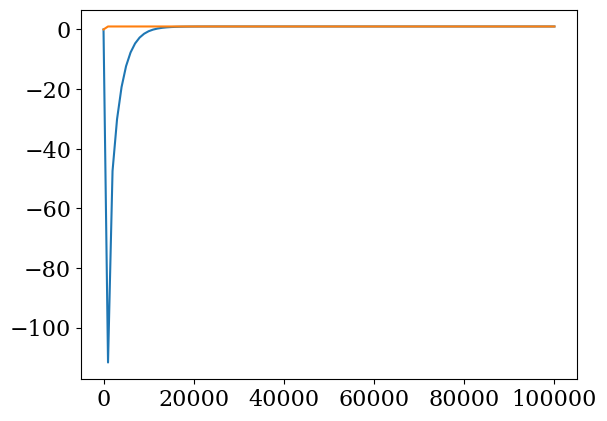

In [13]:
import matplotlib.pyplot as plt
plt.plot(wall.dump.t,wall.dump.qppbnd[:,1])
plt.plot(wall.dump.t,wall.dump.qppbnd[:,0])

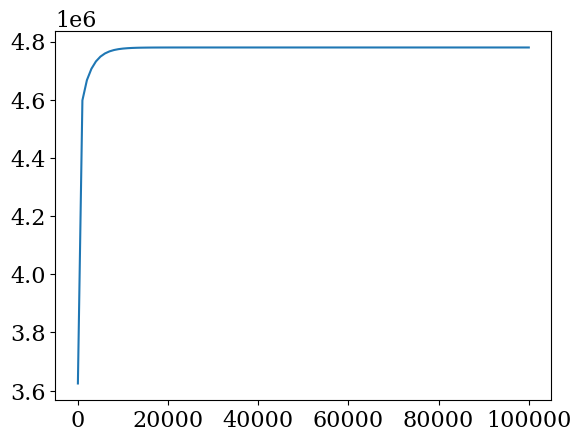

In [14]:
plt.plot(wall.dump.t,wall.dump.enthalpy)

In [17]:
wall.dump.T.shape

(101, 31, 2)

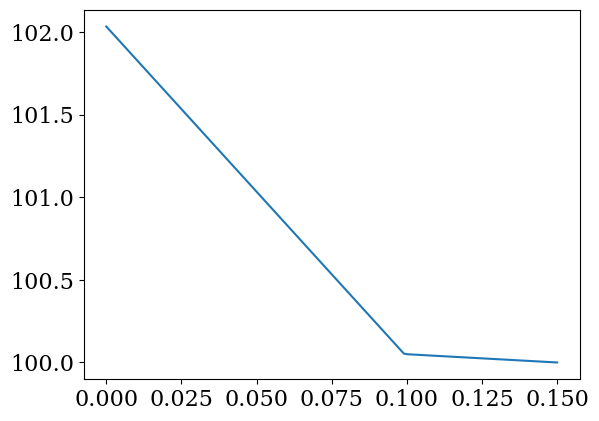

In [18]:
plt.plot(wall.dump.T[-1,:,0],wall.dump.T[-1,:,1])

In [ ]:
wall.dump.qppbnd.shape

In [ ]:
Tsmp = np.concatenate((Tsamples,Tsamples),axis=0)
Tsmp = np.concatenate((Tsmp,Tsamples),axis=0)


In [ ]:
Tsmp[0,:,1]

In [ ]:
plt.plot(wall.grid.xs,wall.T)

In [ ]:
Nlayers = 1
xlayers = np.array([[0.0 , 1.0]])
bcnames = ['Neumann', 'Dirichlet']
wall = ConductionDomain(Nlayers,xlayers,bcnames)
wall.create_grid([21],0.01)
wall.set_layers_thermodynamic_properties(k_per_layer=[0.05], rho_per_layer=[20.], 
                                         Cp_per_layer=[1400.],qdot_per_layer=[0.])
wall.bc.set_value('x0',1.0)
wall.bc.set_value('x1',10.0)
wall.create_metrics()

In [ ]:
n = 0
wall.grid.xs_layer[n]

In [ ]:
wall.solve_steady()

In [ ]:
wall.k.shape

In [ ]:
plt.plot(wall.grid.xs,wall.T)
plt.grid(True)

In [ ]:
wall.k*(wall.metrics.Dx*wall.T)

In [20]:
Nlayers = 2
xlayers = np.array([[0.0 , 1.0],[1.0, 1.5]])
bcnames = ['Neumann', 'Dirichlet']
wall = num.ConductionDomain(Nlayers,xlayers,bcnames)
wall.create_grid([20,10],0.01)
wall.set_layers_thermodynamic_properties(k_per_layer=[0.05, 0.1], rho_per_layer=[20., 1000.], 
                                         Cp_per_layer=[1400., 1000.],qdot_per_layer=[0., 0.])
wall.bc.set_value('x0',-1.0)
wall.bc.set_value('x1',10.0)
wall.create_metrics()


In [21]:
wall.grid.nodeends_layer[1]

[19, 28]

In [22]:
wall.grid.xs.shape

(29,)

In [23]:
wall.metrics.Dx_layer[1]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30 stored elements and shape (10, 10)>

In [24]:
wall.solve_steady()

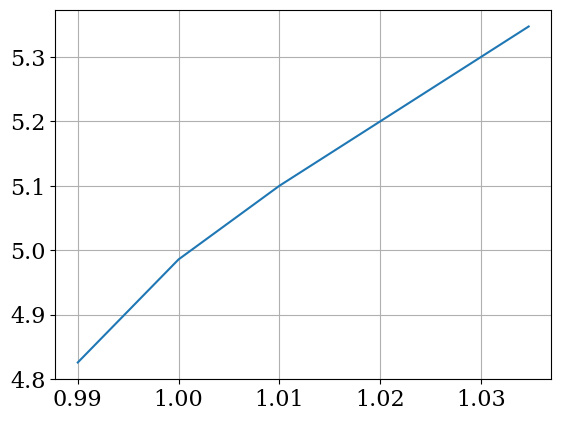

In [25]:
plt.plot(wall.grid.xs[18:22],wall.T[18:22])
plt.grid(True)

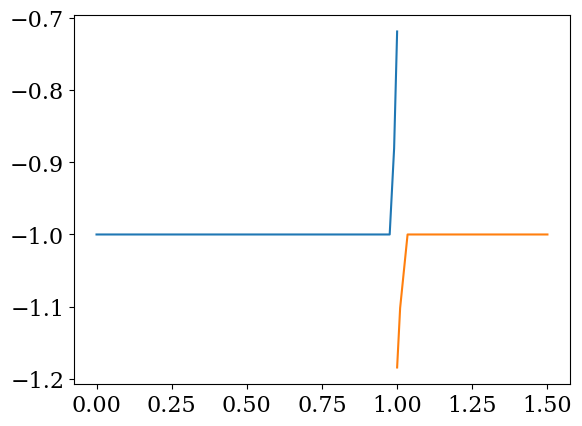

In [26]:
plt.plot(wall.grid.xs_layer[0],-wall.k_per_layer[0]*
         (wall.metrics.Dx_layer[0]*wall.T[wall.grid.nodeends_layer[0][0]:wall.grid.nodeends_layer[0][1]+1]))
plt.plot(wall.grid.xs_layer[1],-wall.k_per_layer[1]*
         (wall.metrics.Dx_layer[1]*wall.T[wall.grid.nodeends_layer[1][0]:wall.grid.nodeends_layer[1][1]+1]))
# plt.ylim(0,)

In [ ]:
plt.plot(wall.grid.xs,wall.k*(wall.metrics.Dx*wall.T))

In [ ]:
wall.grid.nodeends_layer[1][0]

In [ ]:
wall.k[16:21]